# 08 - Multi-Horizon Price-Drop Modelling

This notebook develops the multi-horizon price-drop model for the Smart Buy Window Predictor.

Separate XGBoost classifiers are trained for three prediction windows: 7-day, 14-day, and 30-day. A meaningful price drop is defined as a future price decrease of at least 5% and at least $5, which avoids treating small or practically insignificant price movements as actionable opportunities.

The notebook covers label construction and validation, baseline comparison, model training with early stopping, threshold selection on validation data, three-zone recommendation evaluation on held-out 2026 data, shopper-style backtesting, and SHAP explainability.

In [2]:
# Cell 2 - Imports and Configuration

from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

CLEAN_DATA_PATH = PROJECT_ROOT / "data/processed/clean_data_v2.csv"
FEATURES_V2_PATH = PROJECT_ROOT / "data/processed/features_v2.csv"
OUTPUT_DIR = PROJECT_ROOT / "models/v2_1"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

HORIZONS = [7, 14, 30]

MIN_DROP_PCT = 0.05
MIN_DROP_ABSOLUTE = 5.0

RANDOM_STATE = 42

print("Project root:", PROJECT_ROOT)
print("Clean data exists:", CLEAN_DATA_PATH.exists())
print("Existing V2 features exists:", FEATURES_V2_PATH.exists())

Project root: /Users/hibaswaidan/Desktop/smart-buy-window-predictor
Clean data exists: True
Existing V2 features exists: True


## Data Loading and Sanity Checks

The V2.1 notebook starts from `clean_data_v2.csv`, because the new 7-day and 30-day targets need to be generated from the cleaned daily price history. The existing `features_v2.csv` is used only to validate that the recreated 14-day label matches the original MVP label.

In [3]:
# Cell 4 - Load Clean V2 Data

df = pd.read_csv(CLEAN_DATA_PATH, parse_dates=["date"])

required_columns = [
    "date",
    "asin",
    "amazon_price",
    "amazon_price_raw_missing",
    "sales_rank",
    "offer_count",
    "new_price_shipping_included",
    "price_source",
    "root_category",
]

missing_columns = [col for col in required_columns if col not in df.columns]

print("Shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Unique ASINs:", df["asin"].nunique())
print("Missing required columns:", missing_columns)

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

df = df.sort_values(["asin", "date"]).reset_index(drop=True)

display(df[required_columns].head())

Shape: (1951779, 20)
Date range: 2015-01-01 00:00:00 to 2026-06-01 00:00:00
Unique ASINs: 922
Missing required columns: []


,date,asin,amazon_price,amazon_price_raw_missing,sales_rank,offer_count,new_price_shipping_included,price_source,root_category
0,2021-03-12,B00002N6J9,46.50,0.0,12.0,2.0,0,AMAZON,Tools & Home Improvement
1,2021-03-13,B00002N6J9,46.50,1.0,10.0,2.0,0,AMAZON,Tools & Home Improvement
2,2021-03-14,B00002N6J9,47.11,0.0,9.0,2.0,0,AMAZON,Tools & Home Improvement
3,2021-03-15,B00002N6J9,46.59,0.0,11.0,2.0,0,AMAZON,Tools & Home Improvement
4,2021-03-16,B00002N6J9,46.78,0.0,11.0,2.0,0,AMAZON,Tools & Home Improvement


## Multi-Horizon Label Construction

A positive label means the selected modelling price drops by at least 5% and at least $5 at any point within the future window.

The prediction window starts at day T+1, not day T, to avoid same-day target leakage. For example, the 14-day label considers prices from day T+1 to day T+14 only.

In [4]:
# Cell 6 - Create Multi-Horizon Future-Drop Labels

def add_future_drop_label(dataframe, horizon, price_col="amazon_price"):
    df_labeled = dataframe.copy()

    future_min_col = f"future_min_price_{horizon}d"
    drop_abs_col = f"future_drop_abs_{horizon}d"
    drop_pct_col = f"future_drop_pct_{horizon}d"
    label_col = f"label_drop_{horizon}d"

    future_min = (
        df_labeled
        .groupby("asin")[price_col]
        .transform(
            lambda s: s.shift(-1)
            .rolling(window=horizon, min_periods=1)
            .min()
            .shift(-(horizon - 1))
        )
    )

    df_labeled[future_min_col] = future_min
    df_labeled[drop_abs_col] = df_labeled[price_col] - df_labeled[future_min_col]
    df_labeled[drop_pct_col] = df_labeled[drop_abs_col] / df_labeled[price_col]

    df_labeled[label_col] = (
        (df_labeled[drop_pct_col] >= MIN_DROP_PCT) &
        (df_labeled[drop_abs_col] >= MIN_DROP_ABSOLUTE)
    ).astype(float)

    df_labeled.loc[df_labeled[future_min_col].isna(), label_col] = np.nan

    return df_labeled


for horizon in HORIZONS:
    df = add_future_drop_label(df, horizon)

label_summary = []

for horizon in HORIZONS:
    label_col = f"label_drop_{horizon}d"
    valid_labels = df[label_col].dropna()

    label_summary.append({
        "horizon": horizon,
        "valid_rows": int(valid_labels.shape[0]),
        "positive_rows": int(valid_labels.sum()),
        "positive_rate": round(float(valid_labels.mean()), 4),
    })

label_summary_df = pd.DataFrame(label_summary)
display(label_summary_df)

,horizon,valid_rows,positive_rows,positive_rate
0,7,1946247,341114,0.1753
1,14,1939793,531294,0.2739
2,30,1925041,771772,0.4009


## Label Validation Against the MVP Target

The recreated 14-day label is compared against the original MVP label from `features_v2.csv` to confirm that the multi-horizon label function is consistent with the original pipeline before proceeding.

In [5]:
# Cell 8 - Validate Recreated 14-Day Label Against Existing V2 Label

old_labels = pd.read_csv(
    FEATURES_V2_PATH,
    usecols=["date", "asin", "label_drop_14d"],
    parse_dates=["date"]
)

comparison = df[["date", "asin", "label_drop_14d"]].merge(
    old_labels,
    on=["date", "asin"],
    how="inner",
    suffixes=("_new", "_old")
)

comparison = comparison.dropna(subset=["label_drop_14d_new", "label_drop_14d_old"])

label_match_rate = (
    comparison["label_drop_14d_new"].astype(int)
    == comparison["label_drop_14d_old"].astype(int)
).mean()

print("Rows compared:", len(comparison))
print("New 14-day positive rate:", round(comparison["label_drop_14d_new"].mean(), 4))
print("Old 14-day positive rate:", round(comparison["label_drop_14d_old"].mean(), 4))
print("Label match rate:", round(label_match_rate, 4))

if label_match_rate < 0.999:
    raise ValueError("The recreated 14-day label does not match the original MVP label.")

Rows compared: 1911211
New 14-day positive rate: 0.2745
Old 14-day positive rate: 0.2745
Label match rate: 1.0


## Feature Engineering

The same V2 feature set is recreated for all three horizons. The features use only information available up to the current date. Future prices are used only to create labels and are not included as model inputs.

In [6]:
# Cell 10 - Create Historical Price, Rank, Offer, Missingness, and Calendar Features

df = df.sort_values(["asin", "date"]).reset_index(drop=True)

df["price_source_amazon"] = (df["price_source"] == "AMAZON").astype(int)

for lag in [1, 7, 14, 30]:
    df[f"price_lag_{lag}"] = df.groupby("asin")["amazon_price"].shift(lag)

for window in [7, 14, 30]:
    df[f"price_rolling_mean_{window}"] = (
        df.groupby("asin")["amazon_price"]
        .transform(lambda s: s.shift(1).rolling(window).mean())
    )
    df[f"price_rolling_std_{window}"] = (
        df.groupby("asin")["amazon_price"]
        .transform(lambda s: s.shift(1).rolling(window).std())
    )

for lag in [7, 14, 30]:
    df[f"price_pct_change_{lag}"] = (
        (df["amazon_price"] - df[f"price_lag_{lag}"]) / df[f"price_lag_{lag}"]
    )

df["price_vs_rolling_mean_30"] = (
    (df["amazon_price"] - df["price_rolling_mean_30"]) / df["price_rolling_mean_30"]
)

df["sales_rank_lag_7"] = df.groupby("asin")["sales_rank"].shift(7)

df["sales_rank_rolling_mean_14"] = (
    df.groupby("asin")["sales_rank"]
    .transform(lambda s: s.shift(1).rolling(14).mean())
)

df["sales_rank_velocity_14"] = (
    (df["sales_rank"] - df.groupby("asin")["sales_rank"].shift(14))
    / df.groupby("asin")["sales_rank"].shift(14)
)

df["sales_rank_missing_flag"] = df["sales_rank"].isna().astype(int)

df["offer_count_lag_7"] = df.groupby("asin")["offer_count"].shift(7)

df["offer_count_rolling_mean_14"] = (
    df.groupby("asin")["offer_count"]
    .transform(lambda s: s.shift(1).rolling(14).mean())
)

df["offer_count_trend_14"] = (
    df["offer_count"] - df.groupby("asin")["offer_count"].shift(14)
)

df["offer_count_missing_flag"] = df["offer_count"].isna().astype(int)

df["amazon_price_raw_missing_rolling_14"] = (
    df.groupby("asin")["amazon_price_raw_missing"]
    .transform(lambda s: s.shift(1).rolling(14).mean())
)

df["price_source_changed"] = (
    df.groupby("asin")["price_source"]
    .transform(lambda s: s != s.shift(1))
    .astype(int)
)

df["price_source_changed_7d"] = (
    df.groupby("asin")["price_source_changed"]
    .transform(lambda s: s.shift(1).rolling(7).max())
)

df["month"] = df["date"].dt.month
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["day_of_week"] = df["date"].dt.dayofweek

print("Feature engineering complete.")
print("Shape:", df.shape)

Feature engineering complete.
Shape: (1951779, 61)


In [7]:
# Cell 11 - Create Retail Event Features

def get_black_friday(year):
    november_first = pd.Timestamp(year=year, month=11, day=1)
    days = pd.date_range(november_first, periods=30, freq="D")
    thursdays = [day for day in days if day.weekday() == 3]
    thanksgiving = thursdays[3]
    return thanksgiving + pd.Timedelta(days=1)


def get_cyber_monday(year):
    return get_black_friday(year) + pd.Timedelta(days=3)


def get_christmas(year):
    return pd.Timestamp(year=year, month=12, day=25)


def days_until_event(date, event_func):
    event_date = event_func(date.year)

    if date > event_date:
        event_date = event_func(date.year + 1)

    return int((event_date - date).days)


df["days_until_black_friday"] = df["date"].apply(lambda date: days_until_event(date, get_black_friday))
df["days_until_cyber_monday"] = df["date"].apply(lambda date: days_until_event(date, get_cyber_monday))
df["days_until_christmas"] = df["date"].apply(lambda date: days_until_event(date, get_christmas))

df["is_black_friday_period"] = (df["days_until_black_friday"] <= 7).astype(int)
df["is_cyber_monday_period"] = (df["days_until_cyber_monday"] <= 7).astype(int)
df["is_christmas_period"] = (df["days_until_christmas"] <= 14).astype(int)

print("Retail event features created.")
display(
    df[
        [
            "date",
            "days_until_black_friday",
            "days_until_cyber_monday",
            "days_until_christmas",
            "is_black_friday_period",
            "is_cyber_monday_period",
            "is_christmas_period",
        ]
    ].head()
)

Retail event features created.


,date,days_until_black_friday,days_until_cyber_monday,days_until_christmas,is_black_friday_period,is_cyber_monday_period,is_christmas_period
0,2021-03-12,259,262,288,0,0,0
1,2021-03-13,258,261,287,0,0,0
2,2021-03-14,257,260,286,0,0,0
3,2021-03-15,256,259,285,0,0,0
4,2021-03-16,255,258,284,0,0,0


In [8]:
# Cell 12 - Create Category Features and Time-Based Splits

expected_category_cols = [
    "root_category_Appliances",
    "root_category_Electronics",
    "root_category_Home & Kitchen",
    "root_category_Sports & Outdoors",
    "root_category_Tools & Home Improvement",
    "root_category_Toys & Games",
]

# Remove existing category dummy columns if this cell is rerun
df = df.drop(columns=[col for col in expected_category_cols if col in df.columns], errors="ignore")

category_dummies = pd.get_dummies(df["root_category"], prefix="root_category", dtype=int)

for col in expected_category_cols:
    if col not in category_dummies.columns:
        category_dummies[col] = 0

df = pd.concat([df, category_dummies[expected_category_cols]], axis=1)

df["split"] = np.where(
    df["date"] < "2025-01-01",
    "train",
    np.where(df["date"] < "2026-01-01", "validation", "test")
)

split_summary = (
    df.groupby("split")
    .agg(
        rows=("asin", "size"),
        unique_asins=("asin", "nunique"),
        start_date=("date", "min"),
        end_date=("date", "max"),
    )
    .reset_index()
)

print("Category features and split column created.")
print("Duplicate columns:", df.columns[df.columns.duplicated()].tolist())
display(split_summary)

Category features and split column created.
Duplicate columns: []


,split,rows,unique_asins,start_date,end_date
0,test,110960,922,2026-01-01,2026-06-01
1,train,1585148,922,2015-01-01,2024-12-31
2,validation,255671,922,2025-01-01,2025-12-31


## Feature Set and Evaluation Helpers

The model uses the same 45 feature columns as the MVP model. Each horizon uses the same input feature set, but has a separate target label, model, and validation-selected decision threshold.

In [9]:
# Cell 14 - Define Shared Feature Columns

FEATURE_COLS = [
    "amazon_price",
    "amazon_price_raw_missing",
    "sales_rank",
    "offer_count",
    "new_price_shipping_included",
    "price_lag_1",
    "price_lag_7",
    "price_lag_14",
    "price_lag_30",
    "price_rolling_mean_7",
    "price_rolling_std_7",
    "price_rolling_mean_14",
    "price_rolling_std_14",
    "price_rolling_mean_30",
    "price_rolling_std_30",
    "price_pct_change_7",
    "price_pct_change_14",
    "price_pct_change_30",
    "price_vs_rolling_mean_30",
    "sales_rank_lag_7",
    "sales_rank_rolling_mean_14",
    "sales_rank_velocity_14",
    "sales_rank_missing_flag",
    "offer_count_lag_7",
    "offer_count_rolling_mean_14",
    "offer_count_trend_14",
    "offer_count_missing_flag",
    "amazon_price_raw_missing_rolling_14",
    "month",
    "week_of_year",
    "day_of_week",
    "price_source_amazon",
    "price_source_changed_7d",
    "root_category_Appliances",
    "root_category_Electronics",
    "root_category_Home & Kitchen",
    "root_category_Sports & Outdoors",
    "root_category_Tools & Home Improvement",
    "root_category_Toys & Games",
    "days_until_black_friday",
    "days_until_cyber_monday",
    "days_until_christmas",
    "is_black_friday_period",
    "is_cyber_monday_period",
    "is_christmas_period",
]

missing_features = [col for col in FEATURE_COLS if col not in df.columns]

print("Number of features:", len(FEATURE_COLS))
print("Missing features:", missing_features)

if missing_features:
    raise ValueError(f"Missing model features: {missing_features}")

duplicate_columns = df.columns[df.columns.duplicated()].tolist()
print("Duplicate columns:", duplicate_columns)

if duplicate_columns:
    raise ValueError(f"Duplicate columns found: {duplicate_columns}")

Number of features: 45
Missing features: []
Duplicate columns: []


## Feature Provenance

All 45 model features are constructed from information available up to the current product-day. Future prices are used only to construct labels and are never included as model inputs.

In [10]:
# Display Feature Provenance

feature_provenance_rows = [
    {
        "feature_group": "Current price",
        "examples": "amazon_price",
        "source": "Observed from cleaned Keepa history",
        "available_at_prediction_time": "Yes",
    },
    {
        "feature_group": "Historical price dynamics",
        "examples": "price_lag_1, price_lag_7, rolling means, rolling standard deviations, percentage changes",
        "source": "Engineered from past prices only",
        "available_at_prediction_time": "Yes",
    },
    {
        "feature_group": "Marketplace rank",
        "examples": "sales_rank, sales_rank_lag_7, sales_rank_rolling_mean_14, sales_rank_velocity_14",
        "source": "Observed or historically engineered from Keepa rank history",
        "available_at_prediction_time": "Yes",
    },
    {
        "feature_group": "Offer-count signals",
        "examples": "offer_count, offer_count_lag_7, offer_count_rolling_mean_14, offer_count_trend_14",
        "source": "Observed or historically engineered from Keepa offer-count history",
        "available_at_prediction_time": "Yes",
    },
    {
        "feature_group": "Missingness and source indicators",
        "examples": "amazon_price_raw_missing, price_source_amazon, price_source_changed_7d",
        "source": "Observed or historically engineered from available marketplace signals",
        "available_at_prediction_time": "Yes",
    },
    {
        "feature_group": "Calendar and retail events",
        "examples": "month, week_of_year, days_until_black_friday, days_until_christmas",
        "source": "Deterministic calendar features",
        "available_at_prediction_time": "Yes",
    },
    {
        "feature_group": "Category indicators",
        "examples": "root_category_Electronics, root_category_Home & Kitchen",
        "source": "Observed product metadata encoded as one-hot features",
        "available_at_prediction_time": "Yes",
    },
]

feature_provenance_df = pd.DataFrame(feature_provenance_rows)
display(feature_provenance_df)

,feature_group,examples,source,available_at_prediction_time
0,Current price,amazon_price,Observed from cleaned Keepa history,Yes
1,Historical price dynamics,"price_lag_1, price_lag_7, rolling means, rolli...",Engineered from past prices only,Yes
2,Marketplace rank,"sales_rank, sales_rank_lag_7, sales_rank_rolli...",Observed or historically engineered from Keepa...,Yes
3,Offer-count signals,"offer_count, offer_count_lag_7, offer_count_ro...",Observed or historically engineered from Keepa...,Yes
4,Missingness and source indicators,"amazon_price_raw_missing, price_source_amazon,...",Observed or historically engineered from avail...,Yes
5,Calendar and retail events,"month, week_of_year, days_until_black_friday, ...",Deterministic calendar features,Yes
6,Category indicators,"root_category_Electronics, root_category_Home ...",Observed product metadata encoded as one-hot f...,Yes


In [11]:
# Cell 15 - Define Metric and Threshold Helper Functions

def evaluate_predictions(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "threshold": round(float(threshold), 3),
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "roc_auc": round(roc_auc_score(y_true, y_prob), 4),
        "pr_auc": round(average_precision_score(y_true, y_prob), 4),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def select_threshold_on_validation(y_true, y_prob):
    rows = []

    for threshold in np.arange(0.05, 0.96, 0.01):
        metrics = evaluate_predictions(y_true, y_prob, threshold)
        rows.append(metrics)

    threshold_df = pd.DataFrame(rows)

    best_row = threshold_df.sort_values(
        ["f1", "precision", "recall"],
        ascending=False
    ).iloc[0]

    return float(best_row["threshold"]), threshold_df

## Baseline Models

Three baselines are evaluated for each prediction horizon before training the main XGBoost models.

- **Majority baseline:** always predicts no meaningful price drop. This establishes the no-skill accuracy floor.
- **Rule-based baseline:** predicts a drop when the current price is at least 5% above its 30-day rolling average.
- **Logistic regression:** a linear classifier trained on the same 45-feature set, with median imputation and standard scaling.

These baselines show whether XGBoost adds meaningful predictive value beyond simpler approaches.

In [12]:
# Cell 17 - Train and Evaluate Baseline Models

baseline_rows = []

for horizon in HORIZONS:
    label_col = f"label_drop_{horizon}d"

    modelling_df = df.dropna(subset=[label_col]).copy()
    modelling_df[FEATURE_COLS] = modelling_df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)

    train_df = modelling_df[modelling_df["split"] == "train"]
    val_df = modelling_df[modelling_df["split"] == "validation"]
    test_df = modelling_df[modelling_df["split"] == "test"]

    X_train = train_df[FEATURE_COLS]
    y_train = train_df[label_col].astype(int)

    X_val = val_df[FEATURE_COLS]
    y_val = val_df[label_col].astype(int)

    X_test = test_df[FEATURE_COLS]
    y_test = test_df[label_col].astype(int)

    # Majority baseline: always predict no meaningful price drop
    majority_prob = np.zeros(len(y_test))
    majority_metrics = evaluate_predictions(y_test, majority_prob, threshold=0.5)

    baseline_rows.append({
        "horizon": horizon,
        "model": "majority_no_drop",
        **majority_metrics,
    })

    # Rule-based baseline: current price is at least 5% above 30-day rolling mean
    rule_prob = (
        test_df["price_vs_rolling_mean_30"].fillna(0) >= MIN_DROP_PCT
    ).astype(float).values

    rule_metrics = evaluate_predictions(y_test, rule_prob, threshold=0.5)

    baseline_rows.append({
        "horizon": horizon,
        "model": "rule_price_above_30d_mean",
        **rule_metrics,
    })

    # Logistic regression baseline
    logistic_model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced")),
        ]
    )

    logistic_model.fit(X_train, y_train)

    logistic_val_prob = logistic_model.predict_proba(X_val)[:, 1]
    logistic_test_prob = logistic_model.predict_proba(X_test)[:, 1]

    logistic_threshold, _ = select_threshold_on_validation(y_val, logistic_val_prob)
    logistic_metrics = evaluate_predictions(y_test, logistic_test_prob, logistic_threshold)

    baseline_rows.append({
        "horizon": horizon,
        "model": "logistic_regression",
        **logistic_metrics,
    })

baseline_results_df = pd.DataFrame(baseline_rows)

display(
    baseline_results_df[
        [
            "horizon",
            "model",
            "threshold",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "pr_auc",
            "tn",
            "fp",
            "fn",
            "tp",
        ]
    ]
)

,horizon,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,7,majority_no_drop,0.50,0.8088,0.0000,0.0000,0.0000,0.5000,0.1912,85269,0,20159,0
1,7,rule_price_above_30d_mean,0.50,0.7540,0.4008,0.5792,0.4737,0.6872,0.3126,67812,17457,8483,11676
2,7,logistic_regression,0.51,0.7542,0.4047,0.6058,0.4852,0.7699,0.4458,67304,17965,7947,12212
3,14,majority_no_drop,0.50,0.7016,0.0000,0.0000,0.0000,0.5000,0.2984,69439,0,29535,0
4,14,rule_price_above_30d_mean,0.50,0.7484,0.5847,0.5418,0.5624,0.6890,0.4535,58073,11366,13534,16001
5,14,logistic_regression,0.48,0.7324,0.5422,0.6634,0.5967,0.7813,0.6043,52896,16543,9941,19594
6,30,majority_no_drop,0.50,0.5747,0.0000,0.0000,0.0000,0.5000,0.4253,48417,0,35829,0
7,30,rule_price_above_30d_mean,0.50,0.7042,0.7360,0.4748,0.5772,0.6744,0.5728,42314,6103,18817,17012
8,30,logistic_regression,0.42,0.7066,0.6294,0.7542,0.6862,0.7863,0.7314,32509,15908,8808,27021


### Baseline Interpretation

The majority baseline highlights why accuracy alone is insufficient for this problem. For the 7-day horizon it achieves 80.88% accuracy by always predicting no drop, but its precision, recall, and F1 are all zero — it never identifies any WAIT opportunity.

The rule-based baseline performs better because current price position relative to the 30-day average is a genuinely informative signal. Logistic regression improves further by combining all 45 features linearly. XGBoost must outperform both to justify its added complexity.

## XGBoost Multi-Horizon Models

One unweighted XGBoost classifier is trained for each prediction horizon. This keeps the V2.1 training strategy consistent with the original MVP model while extending the task from one horizon to three horizons.

Early stopping is applied using the validation split. This allows the model to stop when validation performance stops improving instead of always using a fixed number of trees.

In [13]:
# Cell 20 - Train Unweighted XGBoost Models with Early Stopping

xgb_rows = []
threshold_tables = {}
trained_models = {}

for horizon in HORIZONS:
    label_col = f"label_drop_{horizon}d"

    modelling_df = df.dropna(subset=[label_col]).copy()
    modelling_df[FEATURE_COLS] = modelling_df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)

    train_df = modelling_df[modelling_df["split"] == "train"]
    val_df = modelling_df[modelling_df["split"] == "validation"]
    test_df = modelling_df[modelling_df["split"] == "test"]

    X_train = train_df[FEATURE_COLS]
    y_train = train_df[label_col].astype(int)

    X_val = val_df[FEATURE_COLS]
    y_val = val_df[label_col].astype(int)

    X_test = test_df[FEATURE_COLS]
    y_test = test_df[label_col].astype(int)

    model = XGBClassifier(
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=50,
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        early_stopping_rounds=50,
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    val_prob = model.predict_proba(X_val)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    selected_threshold, threshold_df = select_threshold_on_validation(y_val, val_prob)

    val_metrics = evaluate_predictions(y_val, val_prob, selected_threshold)
    test_metrics = evaluate_predictions(y_test, test_prob, selected_threshold)

    xgb_rows.append({
        "horizon": horizon,
        "model": "xgboost_unweighted",
        "train_rows": len(train_df),
        "validation_rows": len(val_df),
        "test_rows": len(test_df),
        "train_positive_rate": round(float(y_train.mean()), 4),
        "validation_positive_rate": round(float(y_val.mean()), 4),
        "test_positive_rate": round(float(y_test.mean()), 4),
        "best_iteration": int(model.best_iteration) if hasattr(model, "best_iteration") else None,
        "selected_threshold": selected_threshold,
        "validation_f1": val_metrics["f1"],
        "validation_precision": val_metrics["precision"],
        "validation_recall": val_metrics["recall"],
        "validation_roc_auc": val_metrics["roc_auc"],
        "validation_pr_auc": val_metrics["pr_auc"],
        "test_accuracy": test_metrics["accuracy"],
        "test_precision": test_metrics["precision"],
        "test_recall": test_metrics["recall"],
        "test_f1": test_metrics["f1"],
        "test_roc_auc": test_metrics["roc_auc"],
        "test_pr_auc": test_metrics["pr_auc"],
        "test_tn": test_metrics["tn"],
        "test_fp": test_metrics["fp"],
        "test_fn": test_metrics["fn"],
        "test_tp": test_metrics["tp"],
    })

    threshold_tables[horizon] = threshold_df
    trained_models[horizon] = model

xgb_results_df = pd.DataFrame(xgb_rows)

display(xgb_results_df)

,horizon,model,train_rows,validation_rows,test_rows,train_positive_rate,validation_positive_rate,test_positive_rate,best_iteration,selected_threshold,validation_f1,validation_precision,validation_recall,validation_roc_auc,validation_pr_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc,test_tn,test_fp,test_fn,test_tp
0,7,xgboost_unweighted,1585148,255671,105428,0.1728,0.1841,0.1912,1074,0.25,0.5185,0.4433,0.6244,0.8093,0.5070,0.7821,0.4513,0.6450,0.5310,0.8130,0.5210,69457,15812,7156,13003
1,14,xgboost_unweighted,1585148,255671,98974,0.2699,0.2889,0.2984,712,0.29,0.6228,0.5487,0.7201,0.8138,0.6421,0.7518,0.5651,0.7310,0.6374,0.8182,0.6575,52821,16618,7946,21589
2,30,xgboost_unweighted,1585148,255647,84246,0.3968,0.4183,0.4253,802,0.33,0.7100,0.6363,0.8030,0.8205,0.7678,0.7343,0.6535,0.7989,0.7189,0.8225,0.7770,33241,15176,7206,28623


### XGBoost Training Results

All three models trained with early stopping. Best iterations were 1074 trees for the 7-day model, 712 for the 14-day model, and 802 for the 30-day model — all below the 2000-tree limit, confirming that training stopped when validation performance plateaued rather than at an arbitrary ceiling.

Performance improves with prediction horizon. The 30-day model achieves the highest F1 because more products have a meaningful drop within a longer window, producing a richer positive class. The 7-day task is the hardest because short-term meaningful drops are less frequent and harder to predict reliably.

## Baseline vs XGBoost Comparison

The final XGBoost models are compared against the baseline models on the held-out test split. This comparison checks whether the selected model provides measurable improvement over simpler approaches.

In [14]:
# Cell 23 - Compare Baselines and XGBoost on the Test Split

xgb_comparison_df = xgb_results_df.rename(
    columns={
        "selected_threshold": "threshold",
        "test_accuracy": "accuracy",
        "test_precision": "precision",
        "test_recall": "recall",
        "test_f1": "f1",
        "test_roc_auc": "roc_auc",
        "test_pr_auc": "pr_auc",
        "test_tn": "tn",
        "test_fp": "fp",
        "test_fn": "fn",
        "test_tp": "tp",
    }
)

xgb_comparison_df = xgb_comparison_df[
    [
        "horizon",
        "model",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "pr_auc",
        "tn",
        "fp",
        "fn",
        "tp",
    ]
]

model_comparison_df = pd.concat(
    [baseline_results_df, xgb_comparison_df],
    ignore_index=True
)

model_comparison_df = model_comparison_df.sort_values(["horizon", "model"]).reset_index(drop=True)

display(model_comparison_df)

,horizon,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,7,logistic_regression,0.51,0.7542,0.4047,0.6058,0.4852,0.7699,0.4458,67304,17965,7947,12212
1,7,majority_no_drop,0.50,0.8088,0.0000,0.0000,0.0000,0.5000,0.1912,85269,0,20159,0
2,7,rule_price_above_30d_mean,0.50,0.7540,0.4008,0.5792,0.4737,0.6872,0.3126,67812,17457,8483,11676
3,7,xgboost_unweighted,0.25,0.7821,0.4513,0.6450,0.5310,0.8130,0.5210,69457,15812,7156,13003
4,14,logistic_regression,0.48,0.7324,0.5422,0.6634,0.5967,0.7813,0.6043,52896,16543,9941,19594
5,14,majority_no_drop,0.50,0.7016,0.0000,0.0000,0.0000,0.5000,0.2984,69439,0,29535,0
6,14,rule_price_above_30d_mean,0.50,0.7484,0.5847,0.5418,0.5624,0.6890,0.4535,58073,11366,13534,16001
7,14,xgboost_unweighted,0.29,0.7518,0.5651,0.7310,0.6374,0.8182,0.6575,52821,16618,7946,21589
8,30,logistic_regression,0.42,0.7066,0.6294,0.7542,0.6862,0.7863,0.7314,32509,15908,8808,27021
9,30,majority_no_drop,0.50,0.5747,0.0000,0.0000,0.0000,0.5000,0.4253,48417,0,35829,0


In [15]:
# Cell 24 - Identify Best Model per Horizon by Test F1

best_by_f1_df = (
    model_comparison_df
    .sort_values(["horizon", "f1"], ascending=[True, False])
    .groupby("horizon")
    .head(1)
    .reset_index(drop=True)
)

display(
    best_by_f1_df[
        [
            "horizon",
            "model",
            "threshold",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "pr_auc",
        ]
    ]
)

,horizon,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,7,xgboost_unweighted,0.25,0.7821,0.4513,0.6450,0.5310,0.8130,0.5210
1,14,xgboost_unweighted,0.29,0.7518,0.5651,0.7310,0.6374,0.8182,0.6575
2,30,xgboost_unweighted,0.33,0.7343,0.6535,0.7989,0.7189,0.8225,0.7770


### Baseline Comparison

XGBoost achieves the best F1, ROC-AUC, and PR-AUC across all three horizons. The majority baseline confirms that accuracy alone is not useful — high accuracy with zero recall means the model never identifies a useful waiting opportunity. The rule-based and logistic regression baselines provide meaningful benchmarks, but XGBoost outperforms both on every ranking metric.

## Threshold Selection

Each XGBoost model outputs a probability. To convert this probability into a WAIT or BUY NOW decision, a threshold is required.

Thresholds were selected independently for each horizon using the validation split only. The selected threshold is the one that maximises validation F1-score. The held-out test split is used only after threshold selection.

In [16]:
# Cell 26 - Show Top Validation Thresholds per Horizon

top_threshold_rows = []

for horizon in HORIZONS:
    threshold_df = threshold_tables[horizon].copy()
    threshold_df["horizon"] = horizon

    top_thresholds = (
        threshold_df
        .sort_values(["f1", "precision", "recall"], ascending=False)
        .head(5)
    )

    top_threshold_rows.append(top_thresholds)

top_thresholds_df = pd.concat(top_threshold_rows, ignore_index=True)

display(
    top_thresholds_df[
        [
            "horizon",
            "threshold",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "pr_auc",
            "tn",
            "fp",
            "fn",
            "tp",
        ]
    ]
)

,horizon,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,7,0.25,0.7865,0.4433,0.6244,0.5185,0.8093,0.5070,171686,36914,17678,29393
1,7,0.24,0.7811,0.4356,0.6401,0.5184,0.8093,0.5070,169568,39032,16942,30129
2,7,0.23,0.7752,0.4279,0.6560,0.5180,0.8093,0.5070,167320,41280,16191,30880
3,7,0.26,0.7911,0.4503,0.6087,0.5176,0.8093,0.5070,173623,34977,18420,28651
4,7,0.27,0.7960,0.4582,0.5930,0.5169,0.8093,0.5070,175591,33009,19158,27913
5,14,0.29,0.7480,0.5487,0.7201,0.6228,0.8138,0.6421,138064,43750,20671,53186
6,14,0.28,0.7439,0.5420,0.7318,0.6228,0.8138,0.6421,136139,45675,19807,54050
7,14,0.30,0.7521,0.5557,0.7077,0.6226,0.8138,0.6421,140021,41793,21587,52270
8,14,0.31,0.7557,0.5623,0.6969,0.6224,0.8138,0.6421,141751,40063,22387,51470
9,14,0.32,0.7589,0.5686,0.6859,0.6218,0.8138,0.6421,143380,38434,23199,50658


In [17]:
# Cell 27 - Selected Threshold Summary

selected_threshold_summary = xgb_results_df[
    [
        "horizon",
        "selected_threshold",
        "validation_f1",
        "validation_precision",
        "validation_recall",
        "validation_roc_auc",
        "validation_pr_auc",
        "test_f1",
        "test_precision",
        "test_recall",
        "test_roc_auc",
        "test_pr_auc",
    ]
].copy()

display(selected_threshold_summary)

,horizon,selected_threshold,validation_f1,validation_precision,validation_recall,validation_roc_auc,validation_pr_auc,test_f1,test_precision,test_recall,test_roc_auc,test_pr_auc
0,7,0.25,0.5185,0.4433,0.6244,0.8093,0.5070,0.5310,0.4513,0.6450,0.8130,0.5210
1,14,0.29,0.6228,0.5487,0.7201,0.8138,0.6421,0.6374,0.5651,0.7310,0.8182,0.6575
2,30,0.33,0.7100,0.6363,0.8030,0.8205,0.7678,0.7189,0.6535,0.7989,0.8225,0.7770


### Threshold Selection Interpretation

The selected thresholds were chosen on the validation split only, then applied unchanged to the held-out test split.

The thresholds differ across horizons because each prediction window has a different positive-label rate and probability distribution. The 7-day model selected a threshold of 0.25, the 14-day model selected 0.29, and the 30-day model selected 0.33.

The validation and test metrics are consistent, which suggests that the selected thresholds generalise reasonably well to the unseen 2026 test period.

## Product Recommendation Thresholds

The F1-selected thresholds are designed for binary model evaluation. The final website requires a separate set of product thresholds that prioritise recommendation reliability over classification F1.

Product thresholds define three zones:
- **BUY NOW:** low predicted drop probability — buying now is the safer choice
- **UNCERTAIN:** moderate probability — no strong recommendation is made
- **WAIT:** high predicted drop probability — waiting is likely to produce a meaningful saving

Thresholds are selected on the validation split only. The selection criterion prioritises a low actual drop rate in the BUY NOW zone, a high actual drop rate in the WAIT zone, low risk of the user paying more by waiting, and reasonable decisive recommendation coverage.

In [18]:
# Cell 30 - Create Future End-of-Window Prices for Conservative Backtest

for horizon in HORIZONS:
    end_price_col = f"future_end_price_{horizon}d"

    if end_price_col not in df.columns:
        df[end_price_col] = (
            df.groupby("asin")["amazon_price"]
            .shift(-horizon)
        )

print("Future end-of-window price columns are ready.")

Future end-of-window price columns are ready.


In [19]:
# Cell 31 - Select Balanced Product Recommendation Thresholds on Validation Split

def evaluate_product_thresholds(
    dataframe,
    probabilities,
    label_col,
    future_min_col,
    future_end_col,
    buy_threshold,
    wait_threshold,
):
    temp_df = dataframe.copy()
    temp_df["drop_probability"] = probabilities

    temp_df["decision"] = np.select(
        [
            temp_df["drop_probability"] <= buy_threshold,
            temp_df["drop_probability"] >= wait_threshold,
        ],
        [
            "BUY_NOW",
            "WAIT",
        ],
        default="UNCERTAIN",
    )

    buy_df = temp_df[temp_df["decision"] == "BUY_NOW"]
    wait_df = temp_df[temp_df["decision"] == "WAIT"]
    uncertain_df = temp_df[temp_df["decision"] == "UNCERTAIN"]
    decisive_df = temp_df[temp_df["decision"].isin(["BUY_NOW", "WAIT"])].copy()

    if len(decisive_df) == 0:
        return None

    wait_mask = decisive_df["decision"] == "WAIT"

    decisive_df["model_price_paid_conservative"] = np.where(
        wait_mask,
        decisive_df[future_end_col],
        decisive_df["amazon_price"]
    )

    decisive_df["saving_conservative"] = (
        decisive_df["amazon_price"] - decisive_df["model_price_paid_conservative"]
    )

    # Conservative saving over all rows, treating UNCERTAIN as no action / zero saving.
    total_conservative_saving = decisive_df["saving_conservative"].sum()
    avg_conservative_saving_all_rows = total_conservative_saving / len(temp_df)

    if len(wait_df) > 0:
        wait_df = wait_df.copy()
        wait_df["wait_end_saving"] = wait_df["amazon_price"] - wait_df[future_end_col]
        pct_wait_pays_more = float((wait_df["wait_end_saving"] < 0).mean())
    else:
        pct_wait_pays_more = np.nan

    return {
        "buy_threshold": round(float(buy_threshold), 3),
        "wait_threshold": round(float(wait_threshold), 3),
        "rows": len(temp_df),
        "buy_now_rows": len(buy_df),
        "uncertain_rows": len(uncertain_df),
        "wait_rows": len(wait_df),
        "buy_now_rate": round(len(buy_df) / len(temp_df), 4),
        "uncertain_rate": round(len(uncertain_df) / len(temp_df), 4),
        "wait_rate": round(len(wait_df) / len(temp_df), 4),
        "decisive_rate": round(len(decisive_df) / len(temp_df), 4),
        "buy_now_actual_drop_rate": round(float(buy_df[label_col].mean()), 4) if len(buy_df) else np.nan,
        "uncertain_actual_drop_rate": round(float(uncertain_df[label_col].mean()), 4) if len(uncertain_df) else np.nan,
        "wait_actual_drop_rate": round(float(wait_df[label_col].mean()), 4) if len(wait_df) else np.nan,
        "avg_conservative_saving_decisive_rows": round(float(decisive_df["saving_conservative"].mean()), 4),
        "avg_conservative_saving_all_rows": round(float(avg_conservative_saving_all_rows), 4),
        "pct_pays_more_decisive_rows": round(float((decisive_df["saving_conservative"] < 0).mean()), 4),
        "pct_wait_pays_more_conservative": round(float(pct_wait_pays_more), 4) if len(wait_df) else np.nan,
    }


product_threshold_rows = []
selected_product_thresholds = {}

BUY_GRID = np.arange(0.05, 0.36, 0.025)
WAIT_GRID = np.arange(0.45, 0.91, 0.025)

MIN_WAIT_RATE = {
    7: 0.02,
    14: 0.05,
    30: 0.08,
}

MIN_DECISIVE_RATE = {
    7: 0.35,
    14: 0.30,
    30: 0.25,
}

MIN_WAIT_DROP_RATE = {
    7: 0.65,
    14: 0.70,
    30: 0.75,
}

MAX_BUY_DROP_RATE = {
    7: 0.15,
    14: 0.15,
    30: 0.18,
}

MAX_WAIT_PAYS_MORE = {
    7: 0.20,
    14: 0.25,
    30: 0.30,
}

for horizon in HORIZONS:
    label_col = f"label_drop_{horizon}d"
    future_min_col = f"future_min_price_{horizon}d"
    future_end_col = f"future_end_price_{horizon}d"

    model = trained_models[horizon]

    modelling_df = df.dropna(subset=[label_col, future_min_col, future_end_col]).copy()
    modelling_df[FEATURE_COLS] = modelling_df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)

    val_df = modelling_df[modelling_df["split"] == "validation"].copy()
    val_prob = model.predict_proba(val_df[FEATURE_COLS])[:, 1]

    horizon_rows = []

    for buy_threshold in BUY_GRID:
        for wait_threshold in WAIT_GRID:
            if buy_threshold >= wait_threshold:
                continue

            metrics = evaluate_product_thresholds(
                dataframe=val_df,
                probabilities=val_prob,
                label_col=label_col,
                future_min_col=future_min_col,
                future_end_col=future_end_col,
                buy_threshold=buy_threshold,
                wait_threshold=wait_threshold,
            )

            if metrics is None:
                continue

            metrics["horizon"] = horizon
            horizon_rows.append(metrics)

    horizon_threshold_df = pd.DataFrame(horizon_rows)

    valid_candidates = horizon_threshold_df[
        (horizon_threshold_df["buy_now_rate"] >= 0.10) &
        (horizon_threshold_df["wait_rate"] >= MIN_WAIT_RATE[horizon]) &
        (horizon_threshold_df["decisive_rate"] >= MIN_DECISIVE_RATE[horizon]) &
        (horizon_threshold_df["buy_now_actual_drop_rate"] <= MAX_BUY_DROP_RATE[horizon]) &
        (horizon_threshold_df["wait_actual_drop_rate"] >= MIN_WAIT_DROP_RATE[horizon]) &
        (horizon_threshold_df["avg_conservative_saving_all_rows"] > 0) &
        (horizon_threshold_df["pct_wait_pays_more_conservative"] <= MAX_WAIT_PAYS_MORE[horizon])
    ].copy()

    if valid_candidates.empty:
        valid_candidates = horizon_threshold_df[
            (horizon_threshold_df["buy_now_rate"] >= 0.10) &
            (horizon_threshold_df["wait_rate"] >= 0.01) &
            (horizon_threshold_df["buy_now_actual_drop_rate"] <= 0.20) &
            (horizon_threshold_df["wait_actual_drop_rate"] >= 0.60) &
            (horizon_threshold_df["avg_conservative_saving_all_rows"] > 0)
        ].copy()

    if valid_candidates.empty:
        raise ValueError(f"No valid product-threshold candidates found for horizon {horizon}.")

    # Balanced product utility score.
    # This favours reliable WAIT recommendations, useful coverage, and conservative saving,
    # while penalising passive-wait risk.
    valid_candidates["product_utility_score"] = (
        (2.0 * valid_candidates["wait_actual_drop_rate"]) +
        (1.0 * (1 - valid_candidates["buy_now_actual_drop_rate"])) +
        (1.0 * valid_candidates["decisive_rate"]) +
        (1.0 * valid_candidates["wait_rate"]) +
        (0.15 * valid_candidates["avg_conservative_saving_all_rows"]) -
        (1.5 * valid_candidates["pct_wait_pays_more_conservative"])
    )

    selected_row = (
        valid_candidates
        .sort_values(
            ["product_utility_score", "avg_conservative_saving_all_rows", "wait_actual_drop_rate"],
            ascending=False
        )
        .iloc[0]
    )

    selected_product_thresholds[horizon] = {
        "buy_threshold": float(selected_row["buy_threshold"]),
        "wait_threshold": float(selected_row["wait_threshold"]),
    }

    product_threshold_rows.append(horizon_threshold_df)

product_threshold_search_df = pd.concat(product_threshold_rows, ignore_index=True)

selected_product_thresholds_df = pd.DataFrame([
    {
        "horizon": horizon,
        **thresholds,
    }
    for horizon, thresholds in selected_product_thresholds.items()
])

display(selected_product_thresholds_df)

,horizon,buy_threshold,wait_threshold
0,7,0.350,0.675
1,14,0.350,0.575
2,30,0.325,0.550


In [21]:
# Cell 32 - Show Selected Product Threshold Performance on Validation Split

selected_threshold_validation_rows = []

for horizon in HORIZONS:
    thresholds = selected_product_thresholds[horizon]

    row = product_threshold_search_df[
        (product_threshold_search_df["horizon"] == horizon) &
        (product_threshold_search_df["buy_threshold"] == thresholds["buy_threshold"]) &
        (product_threshold_search_df["wait_threshold"] == thresholds["wait_threshold"])
    ].copy()

    selected_threshold_validation_rows.append(row)

selected_product_threshold_validation_df = pd.concat(
    selected_threshold_validation_rows,
    ignore_index=True
)

display(
    selected_product_threshold_validation_df[
        [
            "horizon",
            "buy_threshold",
            "wait_threshold",
            "buy_now_rate",
            "uncertain_rate",
            "wait_rate",
            "decisive_rate",
            "buy_now_actual_drop_rate",
            "uncertain_actual_drop_rate",
            "wait_actual_drop_rate",
            "avg_conservative_saving_decisive_rows",
            "avg_conservative_saving_all_rows",
            "pct_pays_more_decisive_rows",
            "pct_wait_pays_more_conservative",
        ]
    ]
)

,horizon,buy_threshold,wait_threshold,buy_now_rate,uncertain_rate,wait_rate,decisive_rate,buy_now_actual_drop_rate,uncertain_actual_drop_rate,wait_actual_drop_rate,avg_conservative_saving_decisive_rows,avg_conservative_saving_all_rows,pct_pays_more_decisive_rows,pct_wait_pays_more_conservative
0,7,0.350,0.675,0.8328,0.1450,0.0222,0.8550,0.1181,0.4754,0.7576,0.5329,0.4556,0.0034,0.1301
1,14,0.350,0.575,0.6796,0.1738,0.1466,0.8262,0.1485,0.4792,0.7138,2.2895,1.8917,0.0302,0.1704
2,30,0.325,0.550,0.4662,0.2185,0.3152,0.7815,0.1724,0.4454,0.7630,2.9504,2.3057,0.0974,0.2415


### Product Threshold Results

Product thresholds were selected on the validation split to produce reliable user-facing recommendations.

| Horizon | BUY NOW threshold | WAIT threshold | WAIT rate | WAIT actual drop rate |
|---|---:|---:|---:|---:|
| 7 days | 0.350 | 0.675 | 2.22% | 75.76% |
| 14 days | 0.350 | 0.575 | 14.66% | 71.38% |
| 30 days | 0.325 | 0.550 | 31.52% | 76.30% |

The 7-day model is highly selective: it rarely recommends WAIT, but when it does, the recommendation is reliable. The 14-day model provides the most balanced behaviour. The 30-day model identifies the most waiting opportunities, but passive waiting carries more risk — under the conservative assumption, 24.15% of 30-day WAIT recommendations result in the user paying more than the current price.

For this reason, 30-day WAIT recommendations should be presented as **WAIT AND TRACK**: the user should monitor the price during the window and buy when the drop occurs, rather than waiting passively until day 30.

## Three-Zone Test Evaluation Using Optimised Product Thresholds

The product thresholds were selected on the validation split. They are now applied unchanged to the held-out 2026 test split.

This evaluates whether the BUY NOW, UNCERTAIN, and WAIT zones generalise to unseen future data.

In [22]:
# Cell 35 - Evaluate Optimised Product Thresholds on Test Split

three_zone_rows = []

for horizon in HORIZONS:
    label_col = f"label_drop_{horizon}d"
    thresholds = selected_product_thresholds[horizon]

    buy_threshold = thresholds["buy_threshold"]
    wait_threshold = thresholds["wait_threshold"]

    model = trained_models[horizon]

    modelling_df = df.dropna(subset=[label_col]).copy()
    modelling_df[FEATURE_COLS] = modelling_df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)

    test_df = modelling_df[modelling_df["split"] == "test"].copy()

    test_df["drop_probability"] = model.predict_proba(test_df[FEATURE_COLS])[:, 1]

    test_df["zone"] = np.select(
        [
            test_df["drop_probability"] <= buy_threshold,
            test_df["drop_probability"] >= wait_threshold,
        ],
        [
            "confident_buy_now",
            "confident_wait",
        ],
        default="uncertain",
    )

    for zone_name, zone_df in test_df.groupby("zone"):
        three_zone_rows.append({
            "horizon": horizon,
            "zone": zone_name,
            "buy_threshold": buy_threshold,
            "wait_threshold": wait_threshold,
            "rows": len(zone_df),
            "row_share": round(len(zone_df) / len(test_df), 4),
            "actual_drop_rate": round(float(zone_df[label_col].mean()), 4),
            "avg_predicted_probability": round(float(zone_df["drop_probability"].mean()), 4),
        })

three_zone_df = pd.DataFrame(three_zone_rows)

zone_order = {
    "confident_buy_now": 0,
    "uncertain": 1,
    "confident_wait": 2,
}

three_zone_df["zone_order"] = three_zone_df["zone"].map(zone_order)
three_zone_df = three_zone_df.sort_values(["horizon", "zone_order"]).drop(columns=["zone_order"])

display(three_zone_df)

,horizon,zone,buy_threshold,wait_threshold,rows,row_share,actual_drop_rate,avg_predicted_probability
0,7,confident_buy_now,0.350,0.675,86742,0.8228,0.1197,0.1124
2,7,uncertain,0.350,0.675,15968,0.1515,0.4835,0.4767
1,7,confident_wait,0.350,0.675,2718,0.0258,0.7568,0.7770
3,14,confident_buy_now,0.350,0.575,66281,0.6697,0.1489,0.1416
5,14,uncertain,0.350,0.575,17119,0.1730,0.4878,0.4611
4,14,confident_wait,0.350,0.575,15574,0.1574,0.7265,0.7137
6,30,confident_buy_now,0.325,0.550,39912,0.4738,0.1758,0.1700
8,30,uncertain,0.325,0.550,17471,0.2074,0.4671,0.4267
7,30,confident_wait,0.325,0.550,26863,0.3189,0.7688,0.7534


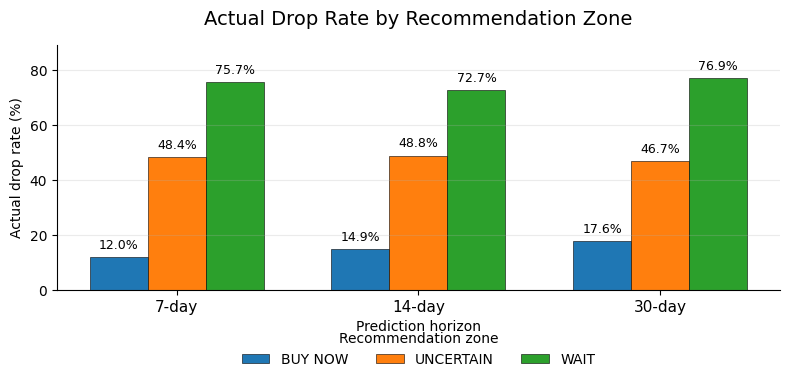

In [30]:
# Plot Three-Zone Actual Drop Rates on the Test Split

import matplotlib.pyplot as plt
import numpy as np

zone_plot_df = three_zone_df.copy()

zone_label_map = {
    "confident_buy_now": "BUY NOW",
    "uncertain": "UNCERTAIN",
    "confident_wait": "WAIT",
}

zone_plot_df["zone_label"] = zone_plot_df["zone"].map(zone_label_map)
zone_plot_df["actual_drop_rate_pct"] = zone_plot_df["actual_drop_rate"] * 100

zone_pivot = zone_plot_df.pivot(
    index="horizon",
    columns="zone_label",
    values="actual_drop_rate_pct"
)

zone_pivot = zone_pivot[["BUY NOW", "UNCERTAIN", "WAIT"]]

fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(len(zone_pivot.index))
bar_width = 0.24

for idx, zone in enumerate(zone_pivot.columns):
    values = zone_pivot[zone].values
    positions = x + (idx - 1) * bar_width

    bars = ax.bar(
        positions,
        values,
        width=bar_width,
        label=zone,
        edgecolor="black",
        linewidth=0.4
    )

    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.1f}%",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.set_title(
    "Actual Drop Rate by Recommendation Zone",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Prediction horizon", fontsize=10)
ax.set_ylabel("Actual drop rate (%)", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels([f"{horizon}-day" for horizon in zone_pivot.index], fontsize=11)

ax.set_ylim(0, max(zone_pivot.max()) + 12)
ax.grid(axis="y", alpha=0.25)

ax.legend(
    title="Recommendation zone",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    frameon=False
)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### Three-Zone Test Evaluation Interpretation

The optimised product thresholds generalise well to the held-out 2026 test split. For every horizon, the actual drop rate increases clearly from BUY NOW to UNCERTAIN to WAIT, showing that the model probabilities create meaningful recommendation zones.

| Horizon | BUY NOW drop rate | UNCERTAIN drop rate | WAIT drop rate |
|---|---:|---:|---:|
| 7 days | 11.97% | 48.35% | 75.68% |
| 14 days | 14.89% | 48.78% | 72.65% |
| 30 days | 17.58% | 46.71% | 76.88% |

The 7-day WAIT zone is very selective, covering only 2.58% of test cases, but it remains reliable. The 14-day model gives a more balanced WAIT coverage of 15.74%, while the 30-day model identifies the most waiting opportunities, with 31.89% of cases in the WAIT zone.

Overall, the three-zone design is suitable for the website because it avoids forcing uncertain cases into strong recommendations while keeping the WAIT zone highly reliable.

## Shopper Backtest Using Optimised Product Thresholds

The three-zone evaluation confirms that the model creates meaningful BUY NOW, UNCERTAIN, and WAIT groups. The next step is to test whether the decisive recommendations create practical savings.

The backtest uses the optimised product thresholds selected on validation data. Only decisive recommendations are evaluated:

- BUY NOW: the simulated shopper buys at the current price.
- WAIT: the simulated shopper waits within the prediction window.
- UNCERTAIN: excluded from the savings calculation because the system does not give a strong recommendation.

Two WAIT assumptions are tested:

- Optimistic WAIT: the shopper buys at the lowest future price within the window.
- Conservative WAIT: the shopper buys at the price at the end of the window.

In [31]:
# Cell 37 - Run Shopper Backtest Using Optimised Product Thresholds

backtest_rows = []

for horizon in HORIZONS:
    label_col = f"label_drop_{horizon}d"
    future_min_col = f"future_min_price_{horizon}d"
    future_end_col = f"future_end_price_{horizon}d"

    thresholds = selected_product_thresholds[horizon]
    buy_threshold = thresholds["buy_threshold"]
    wait_threshold = thresholds["wait_threshold"]

    model = trained_models[horizon]

    modelling_df = df.dropna(subset=[label_col, future_min_col, future_end_col]).copy()
    modelling_df[FEATURE_COLS] = modelling_df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)

    test_df = modelling_df[modelling_df["split"] == "test"].copy()

    test_df["drop_probability"] = model.predict_proba(test_df[FEATURE_COLS])[:, 1]

    test_df["model_decision"] = np.select(
        [
            test_df["drop_probability"] <= buy_threshold,
            test_df["drop_probability"] >= wait_threshold,
        ],
        [
            "BUY_NOW",
            "WAIT",
        ],
        default="UNCERTAIN",
    )

    decisive_df = test_df[test_df["model_decision"].isin(["BUY_NOW", "WAIT"])].copy()
    wait_mask = decisive_df["model_decision"] == "WAIT"

    decisive_df["always_buy_now_price"] = decisive_df["amazon_price"]
    decisive_df["oracle_price"] = decisive_df[future_min_col]

    decisive_df["optimistic_model_price_paid"] = np.where(
        wait_mask,
        decisive_df[future_min_col],
        decisive_df["amazon_price"]
    )

    decisive_df["conservative_model_price_paid"] = np.where(
        wait_mask,
        decisive_df[future_end_col],
        decisive_df["amazon_price"]
    )

    decision_counts = test_df["model_decision"].value_counts(normalize=True)

    for backtest_type, price_col in [
        ("optimistic_wait_best_future_price", "optimistic_model_price_paid"),
        ("conservative_wait_end_price", "conservative_model_price_paid"),
    ]:
        saving_col = f"{backtest_type}_saving"
        regret_col = f"{backtest_type}_regret"

        decisive_df[saving_col] = decisive_df["always_buy_now_price"] - decisive_df[price_col]
        decisive_df[regret_col] = decisive_df[price_col] - decisive_df["oracle_price"]

        backtest_rows.append({
            "horizon": horizon,
            "backtest_type": backtest_type,
            "all_test_rows": len(test_df),
            "decisive_rows": len(decisive_df),
            "decisive_rate": round(len(decisive_df) / len(test_df), 4),
            "buy_now_rate": round(float(decision_counts.get("BUY_NOW", 0)), 4),
            "wait_rate": round(float(decision_counts.get("WAIT", 0)), 4),
            "uncertain_rate": round(float(decision_counts.get("UNCERTAIN", 0)), 4),
            "avg_price_if_buy_now": round(float(decisive_df["always_buy_now_price"].mean()), 2),
            "avg_price_paid_by_model": round(float(decisive_df[price_col].mean()), 2),
            "avg_oracle_price": round(float(decisive_df["oracle_price"].mean()), 2),
            "avg_saving_vs_buy_now": round(float(decisive_df[saving_col].mean()), 2),
            "median_saving_vs_buy_now": round(float(decisive_df[saving_col].median()), 2),
            "avg_regret_vs_oracle": round(float(decisive_df[regret_col].mean()), 2),
            "pct_model_saves_money": round(float((decisive_df[saving_col] > 0).mean()), 4),
            "pct_model_same_price": round(float((decisive_df[saving_col] == 0).mean()), 4),
            "pct_model_pays_more": round(float((decisive_df[saving_col] < 0).mean()), 4),
        })

backtest_df = pd.DataFrame(backtest_rows)

display(
    backtest_df[
        [
            "horizon",
            "backtest_type",
            "all_test_rows",
            "decisive_rows",
            "decisive_rate",
            "buy_now_rate",
            "wait_rate",
            "uncertain_rate",
            "avg_saving_vs_buy_now",
            "median_saving_vs_buy_now",
            "avg_regret_vs_oracle",
            "pct_model_saves_money",
            "pct_model_same_price",
            "pct_model_pays_more",
        ]
    ]
)

,horizon,backtest_type,all_test_rows,decisive_rows,decisive_rate,buy_now_rate,wait_rate,uncertain_rate,avg_saving_vs_buy_now,median_saving_vs_buy_now,avg_regret_vs_oracle,pct_model_saves_money,pct_model_same_price,pct_model_pays_more
0,7,optimistic_wait_best_future_price,104506,88694,0.8487,0.8229,0.0258,0.1513,1.10,0.0,1.71,0.0256,0.9739,0.0005
1,7,conservative_wait_end_price,104506,88694,0.8487,0.8229,0.0258,0.1513,0.77,0.0,2.05,0.0207,0.9758,0.0035
2,14,optimistic_wait_best_future_price,98052,81105,0.8272,0.6697,0.1574,0.1728,4.55,0.0,1.85,0.1632,0.8341,0.0028
3,14,conservative_wait_end_price,98052,81105,0.8272,0.6697,0.1574,0.1728,2.91,0.0,3.49,0.1274,0.8442,0.0284
4,30,optimistic_wait_best_future_price,83329,66060,0.7928,0.4738,0.3189,0.2072,8.80,0.0,1.62,0.3696,0.6269,0.0035
5,30,conservative_wait_end_price,83329,66060,0.7928,0.4738,0.3189,0.2072,3.12,0.0,7.30,0.2305,0.6728,0.0967


### Shopper Backtest Results

The backtest evaluates practical recommendation quality using the optimised product thresholds. Only decisive recommendations are included — BUY NOW and WAIT. UNCERTAIN cases are excluded because the system intentionally withholds a strong recommendation when confidence is moderate.

The model gives a decisive recommendation for 84.87% of 7-day, 82.72% of 14-day, and 79.28% of 30-day test cases.

Under the optimistic tracking assumption, where the user monitors the product and buys at the lowest future price within the window, average savings are $1.10, $4.55, and $8.80 for the 7-day, 14-day, and 30-day horizons respectively, with a very low risk of paying more.

Under the conservative assumption, where the user waits passively until the end of the window, savings are smaller and the risk of paying more increases significantly for the 30-day horizon (9.67% of cases). This reinforces the design decision to frame 30-day WAIT recommendations as **WAIT AND TRACK** rather than a passive instruction to wait until day 30.

## SHAP Explainability

SHAP analysis is applied to all three models on a 5,000-row validation sample. This shows which features drive predictions for each horizon and whether the models rely on consistent and interpretable signals across the three prediction windows.

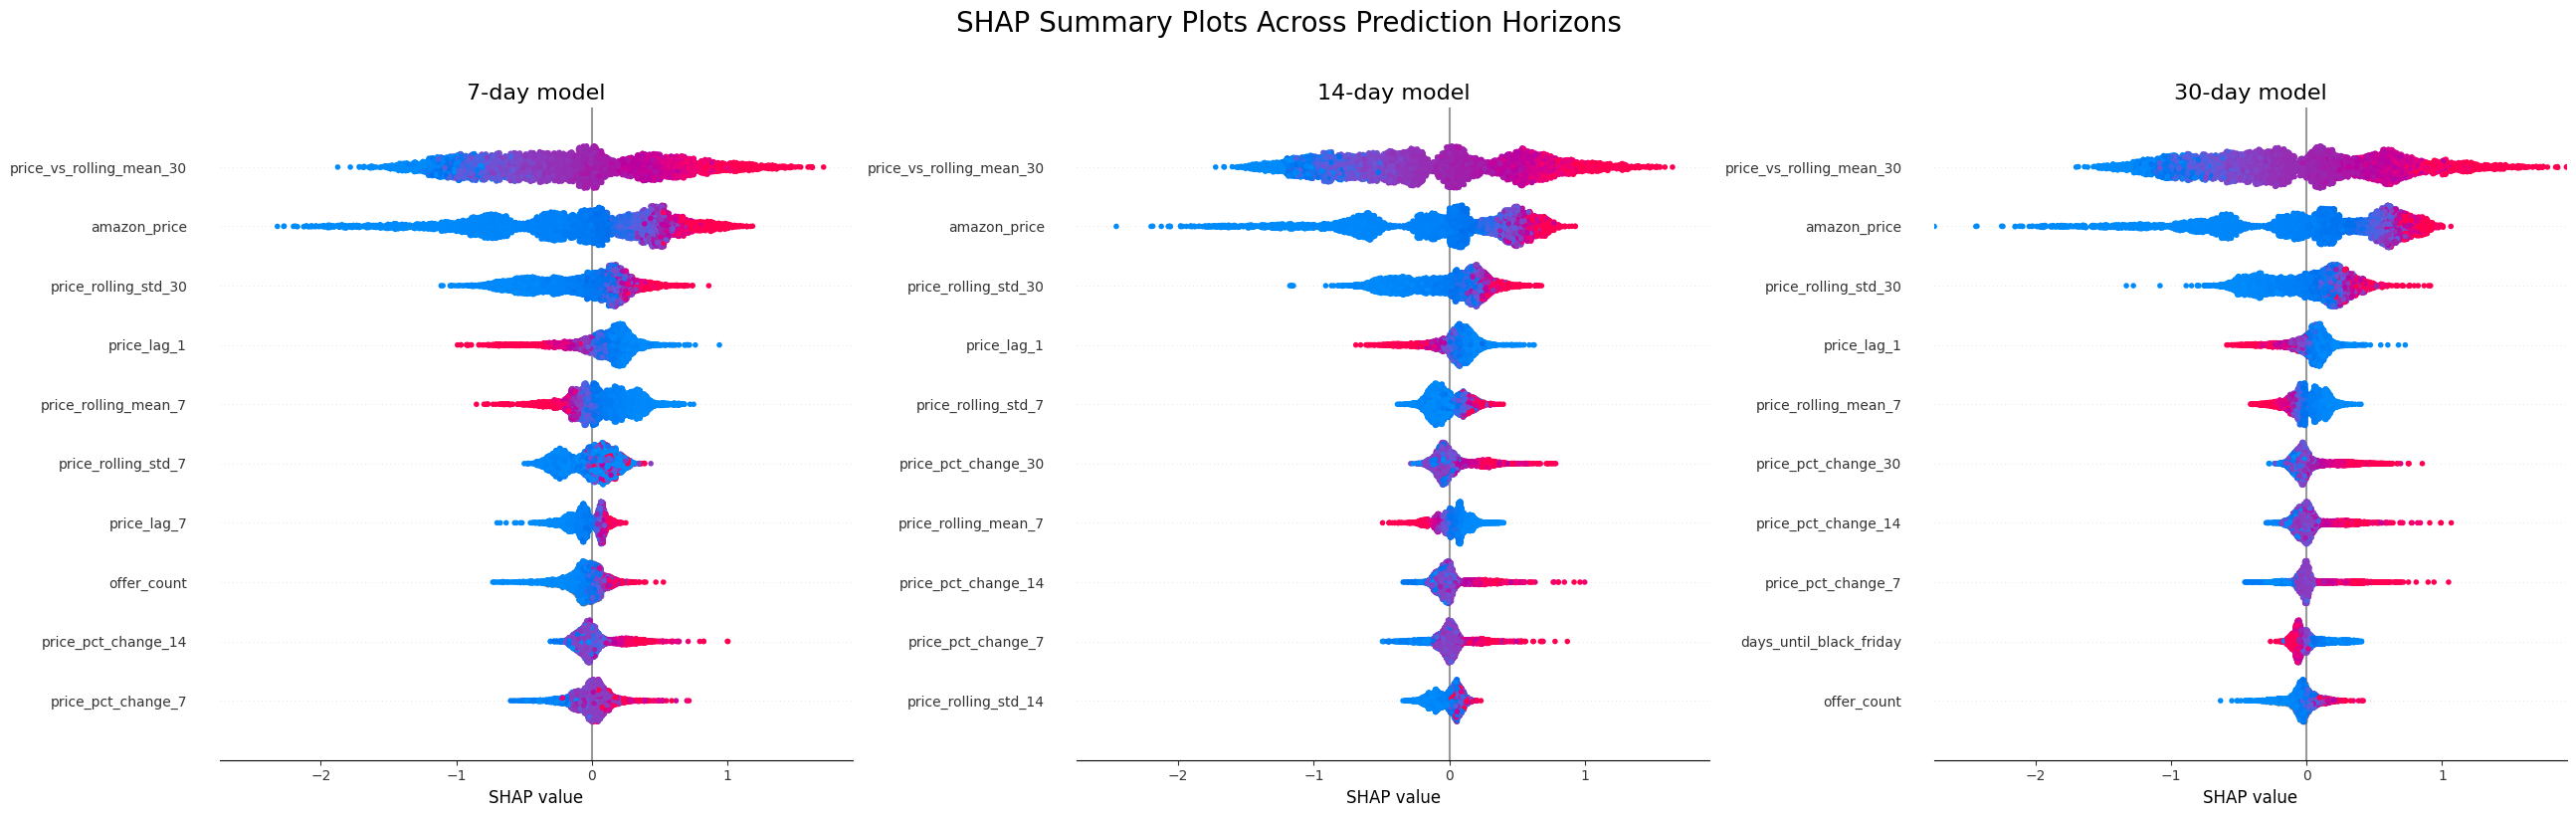

rank,feature,mean_abs_shap
1,price_vs_rolling_mean_30,0.5747
2,amazon_price,0.5171
3,price_rolling_std_30,0.2710
4,price_lag_1,0.1941
5,price_rolling_mean_7,0.1865
6,price_rolling_std_7,0.1437
7,price_lag_7,0.1041
8,offer_count,0.0999
9,price_pct_change_14,0.0990
10,price_pct_change_7,0.0959


In [32]:
# Cell 39 - SHAP Explainability Across All Horizons

import shap
import matplotlib.pyplot as plt
from IPython.display import display, HTML

SHAP_SAMPLE_SIZE = 5000
MAX_DISPLAY_FEATURES = 10
TOP_N_TABLE_FEATURES = 10

shap_summary_rows = []
shap_plot_data = {}

for horizon in HORIZONS:
    label_col = f"label_drop_{horizon}d"

    modelling_df = df.dropna(subset=[label_col]).copy()
    modelling_df[FEATURE_COLS] = modelling_df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)

    val_df = modelling_df[modelling_df["split"] == "validation"].copy()

    X_val_shap = val_df[FEATURE_COLS].sample(
        n=min(SHAP_SAMPLE_SIZE, len(val_df)),
        random_state=RANDOM_STATE
    )

    model = trained_models[horizon]
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_val_shap)

    shap_plot_data[horizon] = {
        "X": X_val_shap,
        "shap_values": shap_values,
    }

    mean_abs_shap = np.abs(shap_values).mean(axis=0)

    horizon_summary = pd.DataFrame({
        "horizon": horizon,
        "feature": FEATURE_COLS,
        "mean_abs_shap": mean_abs_shap
    }).sort_values("mean_abs_shap", ascending=False)

    horizon_summary["rank"] = range(1, len(horizon_summary) + 1)
    shap_summary_rows.append(horizon_summary)

shap_summary_df = pd.concat(shap_summary_rows, ignore_index=True)

global_shap_min = min(
    shap_plot_data[horizon]["shap_values"].min()
    for horizon in HORIZONS
)

global_shap_max = max(
    shap_plot_data[horizon]["shap_values"].max()
    for horizon in HORIZONS
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(26, 8),
    sharex=True
)

for ax, horizon in zip(axes, HORIZONS):
    plt.sca(ax)

    shap.summary_plot(
        shap_plot_data[horizon]["shap_values"],
        shap_plot_data[horizon]["X"],
        max_display=MAX_DISPLAY_FEATURES,
        show=False,
        plot_size=None,
        color_bar=False
    )

    ax.set_title(f"{horizon}-day model", fontsize=16)
    ax.set_xlim(global_shap_min, global_shap_max)
    ax.set_xlabel("SHAP value", fontsize=12)
    ax.tick_params(axis="y", labelsize=10)
    ax.tick_params(axis="x", labelsize=10)

fig.suptitle(
    "SHAP Summary Plots Across Prediction Horizons",
    fontsize=20,
    y=1.02
)

plt.tight_layout()
plt.show()

tables_html = """
<h3>Top SHAP Features by Horizon</h3>
<p style="font-size:14px;">
The tables report mean absolute SHAP values, where larger values indicate greater average influence on the model prediction.
</p>
"""

for horizon in HORIZONS:
    horizon_table = (
        shap_summary_df[
            (shap_summary_df["horizon"] == horizon) &
            (shap_summary_df["rank"] <= TOP_N_TABLE_FEATURES)
        ][["rank", "feature", "mean_abs_shap"]]
        .copy()
    )

    horizon_table["mean_abs_shap"] = horizon_table["mean_abs_shap"].round(4)

    tables_html += f"""
    <div style="display:inline-block; vertical-align:top; width:32%; margin-right:1%;">
        <h4>{horizon}-day model</h4>
        {horizon_table.to_html(index=False)}
    </div>
    """

display(HTML(tables_html))

### SHAP Interpretation

The SHAP analysis shows that all three models are mainly driven by price-history features. The most important feature across the 7-day, 14-day, and 30-day models is `price_vs_rolling_mean_30`, which measures whether the current price is high or low compared with its recent 30-day average.

Other influential features include the current Amazon price, recent price volatility, lagged prices, and percentage price changes. This is consistent with the modelling objective because these features directly describe price behaviour and discount potential.

The similarity of the top features across horizons supports the reliability of the multi-horizon approach. The models are learning consistent price-drop signals while still adapting to different prediction windows.

In [33]:
# Save Final Model Artifacts and Evaluation Outputs

stale_files = [
    OUTPUT_DIR / "three_zone_evaluation.csv",
]

for stale_file in stale_files:
    if stale_file.exists():
        stale_file.unlink()
        print(f"Removed stale file: {stale_file}")

metadata = {
    "model_version": "v2_1_multihorizon",
    "horizons": HORIZONS,
    "label_definition": {
        "minimum_drop_percentage": MIN_DROP_PCT,
        "minimum_absolute_drop": MIN_DROP_ABSOLUTE,
        "description": (
            "Positive label means the selected modelling price drops by at least "
            "5% and at least $5 within the future horizon window."
        ),
    },
    "training_setup": {
        "model_family": "XGBoost",
        "class_weighting": "unweighted",
        "eval_metric": "auc",
        "early_stopping_rounds": 50,
        "n_estimators_limit": 2000,
        "note": (
            "The final setup follows the original MVP modelling style while extending "
            "the prediction task to 7-day, 14-day, and 30-day horizons."
        ),
    },
    "threshold_selection": {
        "classification_threshold_method": "validation_f1_maximisation",
        "classification_threshold_grid": "0.05 to 0.95 in 0.01 increments",
        "product_threshold_method": "validation_optimised_recommendation_thresholds",
        "selected_product_thresholds": selected_product_thresholds,
        "note": (
            "F1-selected thresholds are used for binary model evaluation. "
            "Validation-optimised product thresholds are used for user-facing BUY NOW, WAIT, and UNCERTAIN zones."
        ),
    },
    "feature_columns": FEATURE_COLS,
    "random_state": RANDOM_STATE,
    "xgboost_results": xgb_results_df.to_dict(orient="records"),
    "best_test_models_by_f1": best_by_f1_df.to_dict(orient="records"),
}

for horizon, model in trained_models.items():
    model_path = OUTPUT_DIR / f"xgb_price_drop_{horizon}d_model.joblib"
    joblib.dump(model, model_path)
    print(f"Saved model: {model_path}")

with open(OUTPUT_DIR / "feature_columns.json", "w") as f:
    json.dump(FEATURE_COLS, f, indent=2)

with open(OUTPUT_DIR / "model_metadata_multihorizon.json", "w") as f:
    json.dump(metadata, f, indent=2)

baseline_results_df.to_csv(OUTPUT_DIR / "baseline_results.csv", index=False)
xgb_results_df.to_csv(OUTPUT_DIR / "xgboost_multihorizon_results.csv", index=False)
model_comparison_df.to_csv(OUTPUT_DIR / "model_comparison_results.csv", index=False)
top_thresholds_df.to_csv(OUTPUT_DIR / "top_thresholds_by_horizon.csv", index=False)
selected_threshold_summary.to_csv(OUTPUT_DIR / "selected_threshold_summary.csv", index=False)
product_threshold_search_df.to_csv(OUTPUT_DIR / "product_threshold_search_results.csv", index=False)
selected_product_thresholds_df.to_csv(OUTPUT_DIR / "selected_product_thresholds.csv", index=False)
selected_product_threshold_validation_df.to_csv(OUTPUT_DIR / "selected_product_threshold_validation_results.csv", index=False)
three_zone_df.to_csv(OUTPUT_DIR / "three_zone_test_evaluation.csv", index=False)
backtest_df.to_csv(OUTPUT_DIR / "shopper_backtest_results.csv", index=False)
shap_summary_df.to_csv(OUTPUT_DIR / "shap_feature_importance.csv", index=False)

print("Saved all V2.1 model artifacts and evaluation outputs.")

Removed stale file: /Users/hibaswaidan/Desktop/smart-buy-window-predictor/models/v2_1/three_zone_evaluation.csv
Saved model: /Users/hibaswaidan/Desktop/smart-buy-window-predictor/models/v2_1/xgb_price_drop_7d_model.joblib
Saved model: /Users/hibaswaidan/Desktop/smart-buy-window-predictor/models/v2_1/xgb_price_drop_14d_model.joblib
Saved model: /Users/hibaswaidan/Desktop/smart-buy-window-predictor/models/v2_1/xgb_price_drop_30d_model.joblib
Saved all V2.1 model artifacts and evaluation outputs.


In [34]:
# Check Saved Files

saved_files = sorted([path.name for path in OUTPUT_DIR.iterdir()])
saved_files

['baseline_results.csv',
 'feature_columns.json',
 'model_comparison_results.csv',
 'model_metadata_multihorizon.json',
 'product_threshold_search_results.csv',
 'selected_product_threshold_validation_results.csv',
 'selected_product_thresholds.csv',
 'selected_threshold_summary.csv',
 'shap_feature_importance.csv',
 'shopper_backtest_results.csv',
 'three_zone_test_evaluation.csv',
 'top_thresholds_by_horizon.csv',
 'xgb_price_drop_14d_model.joblib',
 'xgb_price_drop_30d_model.joblib',
 'xgb_price_drop_7d_model.joblib',
 'xgboost_multihorizon_results.csv']

## Final Summary

This notebook developed the V2.1 multi-horizon model for the Smart Buy Window Predictor. The system is designed for online shoppers who want support deciding whether to buy now, wait briefly, wait longer while tracking the product, or treat the prediction as uncertain.

The modelling task was formulated as three separate binary prediction problems: whether a meaningful price drop will occur within 7, 14, or 30 days. A meaningful price drop was defined as a decrease of at least 5% and at least $5, ensuring that the target reflects practically useful savings rather than small price fluctuations.

The dataset was built from cleaned historical Keepa product data, with 1,951,779 product-day rows across 922 ASINs. Features were constructed from information available up to each product-day, including price lags, rolling price statistics, volatility, recent price changes, offer-count signals, price-source indicators, missingness features, calendar effects, and product-category indicators. Future prices were used only to construct labels.

To reduce temporal leakage, the notebook used a chronological split: data before 2025 for training, 2025 for validation and threshold selection, and 2026 for final testing. The recreated 14-day label matched the original MVP label exactly, confirming that the multi-horizon formulation is consistent with the validated MVP pipeline.

Baseline models were evaluated before the final model, including a majority baseline, a rule-based price-position baseline, and logistic regression. XGBoost achieved the best F1-score across all three horizons, showing that it adds predictive value beyond simple rules and linear classification.

The final XGBoost test results were:

| Horizon | ROC-AUC | PR-AUC | F1 | Precision | Recall | Accuracy |
|---|---:|---:|---:|---:|---:|---:|
| 7 days | 0.8130 | 0.5210 | 0.5310 | 0.4513 | 0.6450 | 0.7821 |
| 14 days | 0.8182 | 0.6575 | 0.6374 | 0.5651 | 0.7310 | 0.7518 |
| 30 days | 0.8225 | 0.7770 | 0.7189 | 0.6535 | 0.7989 | 0.7343 |

The notebook separates model evaluation from product recommendation logic. F1-selected thresholds were used for binary model evaluation, while validation-optimised product thresholds were used to create BUY NOW, UNCERTAIN, and WAIT recommendation zones.

On the held-out 2026 test split, the recommendation zones showed clear separation:

| Horizon | BUY NOW drop rate | UNCERTAIN drop rate | WAIT drop rate |
|---|---:|---:|---:|
| 7 days | 11.97% | 48.35% | 75.68% |
| 14 days | 14.89% | 48.78% | 72.65% |
| 30 days | 17.58% | 46.71% | 76.88% |

This shows that the model probabilities are useful for recommendation grouping. The system does not force every product into a strong decision. Moderate-confidence products are labelled UNCERTAIN, which is more appropriate when product behaviour is less predictable.

A shopper-style backtest was used to evaluate practical usefulness beyond accuracy. Under the optimistic tracking assumption, where the user monitors the product and buys at the lowest future price, the model produced average savings of $1.10, $4.55, and $8.80 for the 7-day, 14-day, and 30-day horizons. Under the conservative assumption, where the user waits until the end of the window, savings were lower but remained positive.

The backtest also showed that 30-day WAIT recommendations should be framed as WAIT AND TRACK rather than passive waiting. This means the user should monitor the product during the predicted window and buy when the price drop occurs.

SHAP explainability showed that all three models are mainly driven by meaningful price-history features, especially current price relative to the 30-day rolling average, current Amazon price, recent volatility, lagged prices, and percentage price changes. The similarity of the top features across horizons supports the reliability of the multi-horizon approach.

Overall, the V2.1 system provides a stronger formulation than the original MVP. It preserves the validated 14-day modelling logic, extends the system to multiple waiting windows, evaluates against baselines, uses time-aware validation, includes uncertainty handling, tests practical recommendation value through backtesting, and provides explainability evidence.

The final V2.1 artifacts were saved under `models/v2_1/` for later integration into the deployed application.